# 📊 Data Visualization Master Cheatsheet
### Matplotlib · Seaborn · Plotly · Bokeh — All Charts in One Place

> **How to use this notebook**  
> Every section is self-contained. Run the **Setup** section once, then jump to any chart type you need. Every example uses **built-in sample data**, so no additional downloads are required.

# 👋 Welcome!

Data visualization is one of the most important skills in Data Analysis, Data Science, Business Intelligence, and Machine Learning. Before building models or making business decisions, it's essential to understand your data visually.

This notebook serves as a **complete visualization cheatsheet**, bringing together the most commonly used chart types across four powerful Python visualization libraries:

- 📈 **Matplotlib** – The foundation of Python plotting
- 🎨 **Seaborn** – Statistical visualizations with beautiful defaults
- ⚡ **Plotly** – Interactive and web-ready visualizations
- 📊 **Bokeh** – Interactive dashboards and large-scale visual analytics

Whether you're a beginner learning visualization for the first time or an experienced analyst looking for a quick reference, this notebook is designed to help you find the right chart quickly and understand when to use it.

---

# 🎯 Objectives

By the end of this notebook, you will be able to:

- ✅ Understand the purpose of the most common chart types
- ✅ Know when each visualization should be used
- ✅ Create professional visualizations using multiple Python libraries
- ✅ Customize charts for better readability and presentation
- ✅ Compare different visualization libraries for the same task
- ✅ Build a strong foundation for Exploratory Data Analysis (EDA)

---

# 📚 What You'll Find

This notebook includes examples of:

- 📈 Line Charts
- 📊 Bar Charts
- 🔵 Scatter Plots
- 🥧 Pie Charts
- 📉 Histograms
- 📦 Box Plots
- 🎻 Violin Plots
- 🌋 KDE Plots
- 🔥 Heatmaps
- 👥 Pair Plots
- 🌳 Treemaps
- 📍 Bubble Charts
- 📌 Area Charts
- 📅 Time Series Visualizations
- 🌍 Geographic Maps
- 📊 Interactive Charts
- And many more...

---

# 💡 Why This Notebook?

Instead of searching through multiple tutorials and documentation pages, this notebook collects the most useful visualization techniques in one place.

Each section includes:

- ✔ A brief explanation of the chart
- ✔ When to use it
- ✔ A complete, runnable example
- ✔ Customization tips
- ✔ Best practices
- ✔ Common use cases

The goal is to create a practical reference that you can revisit whenever you need the right visualization for your data.

---

⭐ **If you find this notebook helpful, consider giving it an upvote and sharing it with others. Happy Learning! 🚀**

## 📚 Table of Contents
1. [Setup & Sample Data](#1-setup)
2. [Matplotlib – Basic Charts](#2-matplotlib-basic)
3. [Matplotlib – Intermediate Charts](#3-matplotlib-intermediate)
4. [Matplotlib – Advanced Charts & Subplots](#4-matplotlib-advanced)
5. [Seaborn – Statistical Charts](#5-seaborn)
6. [Seaborn – Plot Customization](#6-seaborn-customization)
7. [Plotly – Interactive Charts](#7-plotly-interactive)
8. [Plotly – Maps & 3-D](#8-plotly-maps)
9. [Bokeh – Web-Ready Interactive Charts](#9-bokeh)
10. [Quick-Reference Cheatsheet](#10-cheatsheet)


---
## 1 · Setup & Sample Data <a id='1-setup'></a>

Install any missing libraries and load two datasets that are used throughout
the notebook:

| Dataset | Source | Shape | Key columns |
|---------|--------|-------|-------------|
| **diamonds** | `seaborn.load_dataset` | 53 940 rows × 10 cols | carat, cut, color, clarity, price |
| **titanic** | `seaborn.load_dataset` | 891 rows × 15 cols | survived, sex, age, pclass, fare |


In [1]:
# ── Install libraries (uncomment if needed) ───────────────────────────────
# !pip install matplotlib seaborn plotly bokeh --quiet

# ── Core imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [2]:
# ── Load sample datasets (no CSV files needed) ───────────────────────────
diamonds = sns.load_dataset('diamonds')   # 53940 diamonds with price, cut, carat …
titanic  = sns.load_dataset('titanic')    # 891 passengers on the Titanic

# Work with a 2 000-row sample of diamonds to keep plots fast
df = diamonds.sample(2000, random_state=42).reset_index(drop=True)

print("diamonds shape:", diamonds.shape)
print("titanic  shape:", titanic.shape)
print()
print("diamonds columns:", list(diamonds.columns))
print()
diamonds.head(3)


diamonds shape: (53940, 10)
titanic  shape: (891, 15)

diamonds columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']



,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


---
## 2 · Matplotlib – Basic Charts <a id='2-matplotlib-basic'></a>

Matplotlib is the **foundation** of Python plotting. Every other library builds
on top of it. The key concept is the `Figure → Axes → Artist` hierarchy:

```
fig, ax = plt.subplots()   # fig = canvas,  ax = the actual plot area
ax.plot(...)               # draw on the axes
plt.show()                 # render
```


### 2.1 Line Plot
Best for: trends over time or a continuous variable.

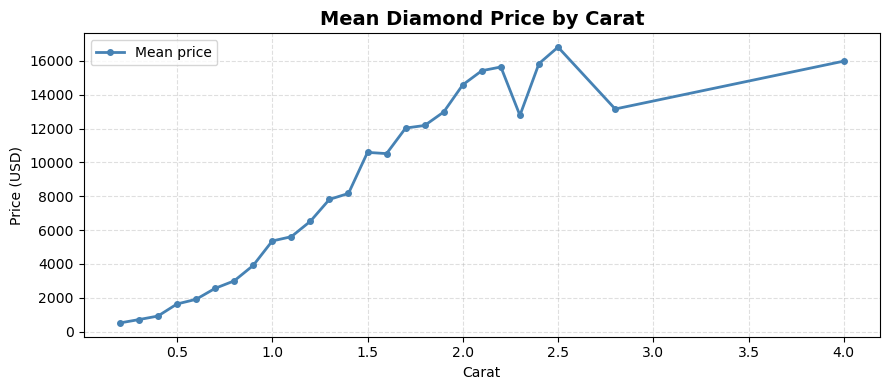

In [3]:
# ── Line Plot ─────────────────────────────────────────────────────────────
# Aggregate: mean price per carat (rounded to 1 decimal)
line_data = (df.assign(carat_bin=df['carat'].round(1))
               .groupby('carat_bin')['price'].mean()
               .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    line_data['carat_bin'],   # x-axis values
    line_data['price'],       # y-axis values
    color='steelblue',        # line colour
    linewidth=2,              # thickness
    marker='o',               # circle marker at each data point
    markersize=4,
    label='Mean price'        # legend entry
)

# Labels & formatting
ax.set_title('Mean Diamond Price by Carat', fontsize=14, fontweight='bold')
ax.set_xlabel('Carat')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
# ► Tip: swap ax.plot() for ax.plot(..., linestyle='--') to get a dashed line


### 2.2 Bar Chart
Best for: comparing categories.

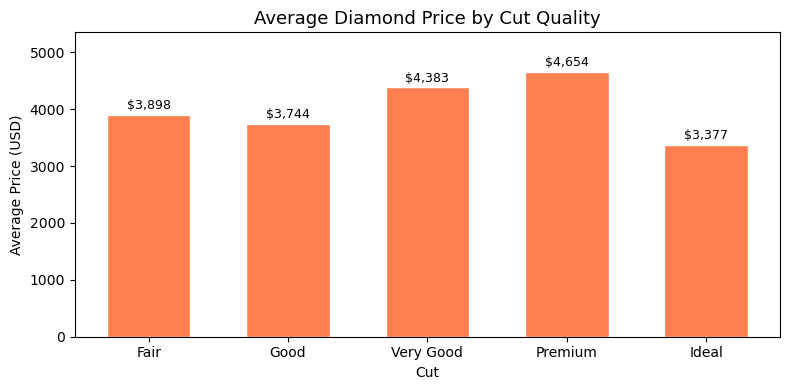

In [4]:
# ── Vertical Bar Chart ────────────────────────────────────────────────────
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
avg_price  = df.groupby('cut')['price'].mean().reindex(cut_order)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    avg_price.index,          # category labels
    avg_price.values,         # bar heights
    color='coral',            # bar colour
    edgecolor='white',        # thin white border makes bars pop
    width=0.6
)

# Add value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x-centre of bar
        bar.get_height() + 50,              # just above the bar
        f'${bar.get_height():,.0f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Average Diamond Price by Cut Quality', fontsize=13)
ax.set_xlabel('Cut')
ax.set_ylabel('Average Price (USD)')
ax.set_ylim(0, avg_price.max() * 1.15)   # leave headroom for labels

plt.tight_layout()
plt.show()
# ► Tip: use ax.barh() for a horizontal bar chart


### 2.3 Scatter Plot
Best for: relationship between two continuous variables.

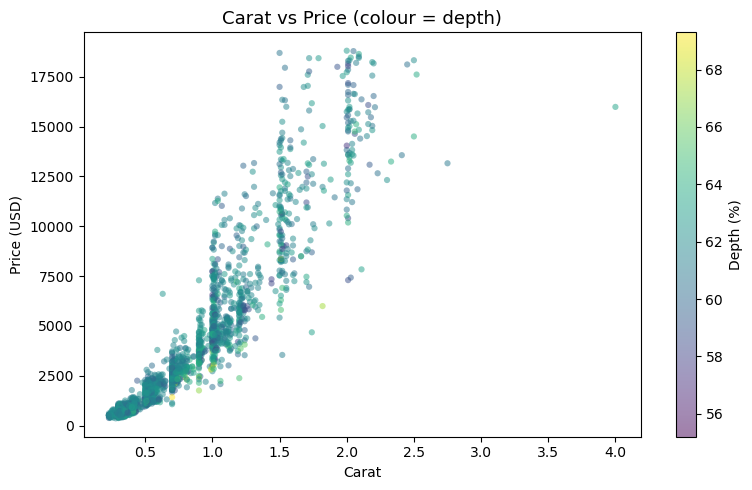

In [5]:
# ── Scatter Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    df['carat'],              # x variable
    df['price'],              # y variable
    c=df['depth'],            # colour encodes a 3rd variable (depth)
    cmap='viridis',           # colour map
    alpha=0.5,                # transparency (0=invisible, 1=solid)
    s=20,                     # marker size in points²
    edgecolors='none'
)

plt.colorbar(scatter, ax=ax, label='Depth (%)')

ax.set_title('Carat vs Price (colour = depth)', fontsize=13)
ax.set_xlabel('Carat')
ax.set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()
# ► Tip: pass s=df['table'] to make dot SIZE encode a 4th variable


### 2.4 Histogram
Best for: distribution of a single variable.

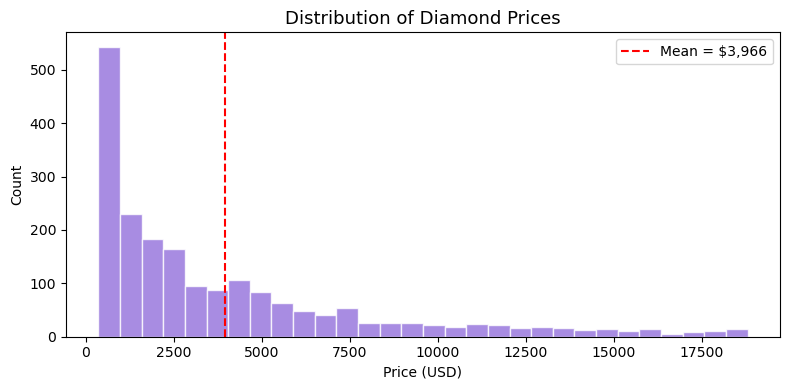

In [6]:
# ── Histogram ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    df['price'],              # data
    bins=30,                  # number of bins (try 10, 20, 50)
    color='mediumpurple',
    edgecolor='white',
    alpha=0.8
)

ax.set_title('Distribution of Diamond Prices', fontsize=13)
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Count')
ax.axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean = ${df['price'].mean():,.0f}")
ax.legend()

plt.tight_layout()
plt.show()
# ► Tip: set density=True to plot a probability density instead of counts


### 2.5 Pie Chart
Best for: part-to-whole when you have ≤ 6 categories.

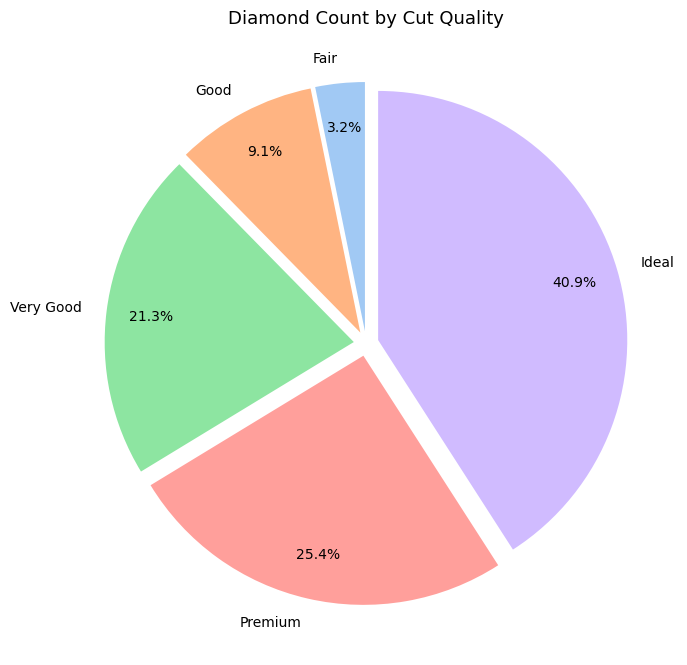

In [7]:
# ── Pie Chart ─────────────────────────────────────────────────────────────
cut_counts = df['cut'].value_counts().reindex(cut_order)

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    cut_counts,
    labels=cut_counts.index,
    autopct='%1.1f%%',        # show percentage inside each slice
    startangle=90,            # rotate so first slice starts at top
    pctdistance=0.82,         # distance of % label from centre
    explode=[0.05] * len(cut_counts),  # slightly separate all slices
    colors=sns.color_palette('pastel')
)

ax.set_title('Diamond Count by Cut Quality', fontsize=13)

plt.tight_layout()
plt.show()
# ► Tip: set explode=[0.1, 0, 0, 0, 0] to pull out only the first slice


---
## 3 · Matplotlib – Intermediate Charts <a id='3-matplotlib-intermediate'></a>


### 3.1 Box Plot
Best for: comparing distributions and spotting outliers.

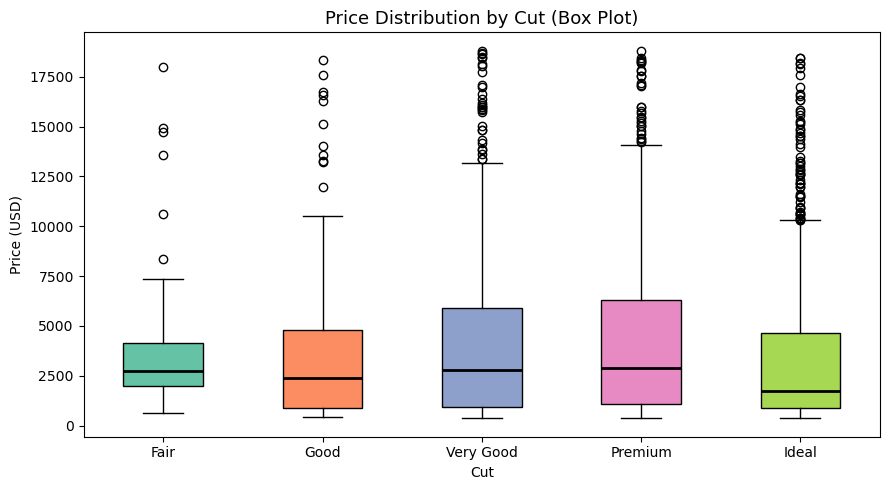

In [8]:
# ── Box Plot ──────────────────────────────────────────────────────────────
# Prepare data: one list per cut category
groups   = [df[df['cut'] == c]['price'].values for c in cut_order]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    groups,
    labels=cut_order,
    patch_artist=True,         # filled boxes (not just outlines)
    notch=False,               # set True for notched box plots
    medianprops=dict(color='black', linewidth=2)
)

# Colour each box differently
colours = sns.color_palette('Set2', len(cut_order))
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)

ax.set_title('Price Distribution by Cut (Box Plot)', fontsize=13)
ax.set_xlabel('Cut')
ax.set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()
# ► Tip: vert=False gives a horizontal box plot


### 3.2 Heatmap (Correlation Matrix)
Best for: visualising correlation between numerical features.

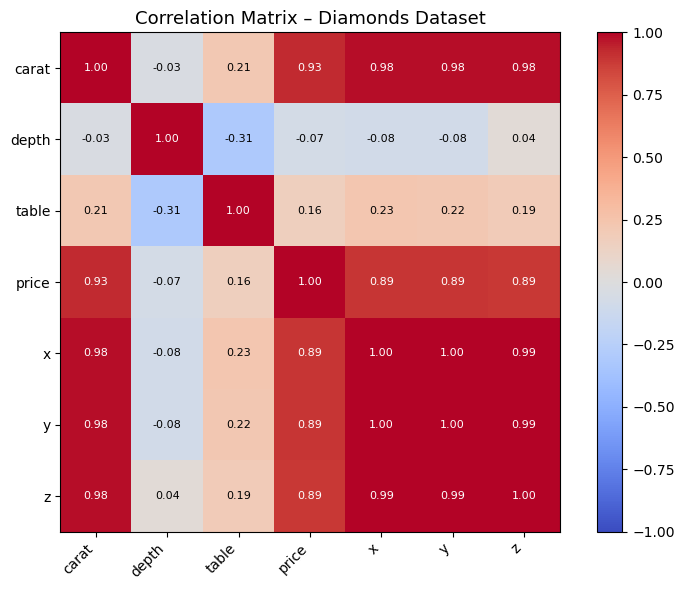

In [9]:
# ── Heatmap of Correlation Matrix ─────────────────────────────────────────
num_cols    = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# imshow plots the matrix as a colour grid
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

# Axis tick labels
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)

# Annotate each cell with the correlation value
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.6 else 'black')

ax.set_title('Correlation Matrix – Diamonds Dataset', fontsize=13)

plt.tight_layout()
plt.show()
# ► Tip: use sns.heatmap() (Section 5) for a one-liner version


### 3.3 Stem Plot
Best for: discrete data where you want to show individual values.

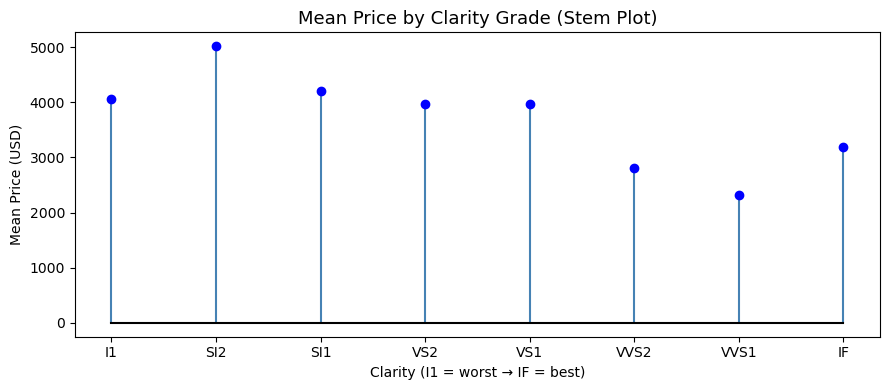

In [10]:
# ── Stem Plot ─────────────────────────────────────────────────────────────
# Show mean price per clarity grade
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
clarity_mean  = df.groupby('clarity')['price'].mean().reindex(clarity_order)

fig, ax = plt.subplots(figsize=(9, 4))

ax.stem(
    clarity_order,
    clarity_mean.values,
    linefmt='steelblue',       # colour of the vertical lines
    markerfmt='bo',            # blue circle markers
    basefmt='k-'               # black horizontal baseline
)

ax.set_title('Mean Price by Clarity Grade (Stem Plot)', fontsize=13)
ax.set_xlabel('Clarity (I1 = worst → IF = best)')
ax.set_ylabel('Mean Price (USD)')

plt.tight_layout()
plt.show()


---
## 4 · Matplotlib – Advanced: Subplots & Figure Layout <a id='4-matplotlib-advanced'></a>

`plt.subplots(rows, cols)` returns a grid of Axes objects. Index them with
`axes[row, col]` (2-D) or `axes[n]` (1-D).


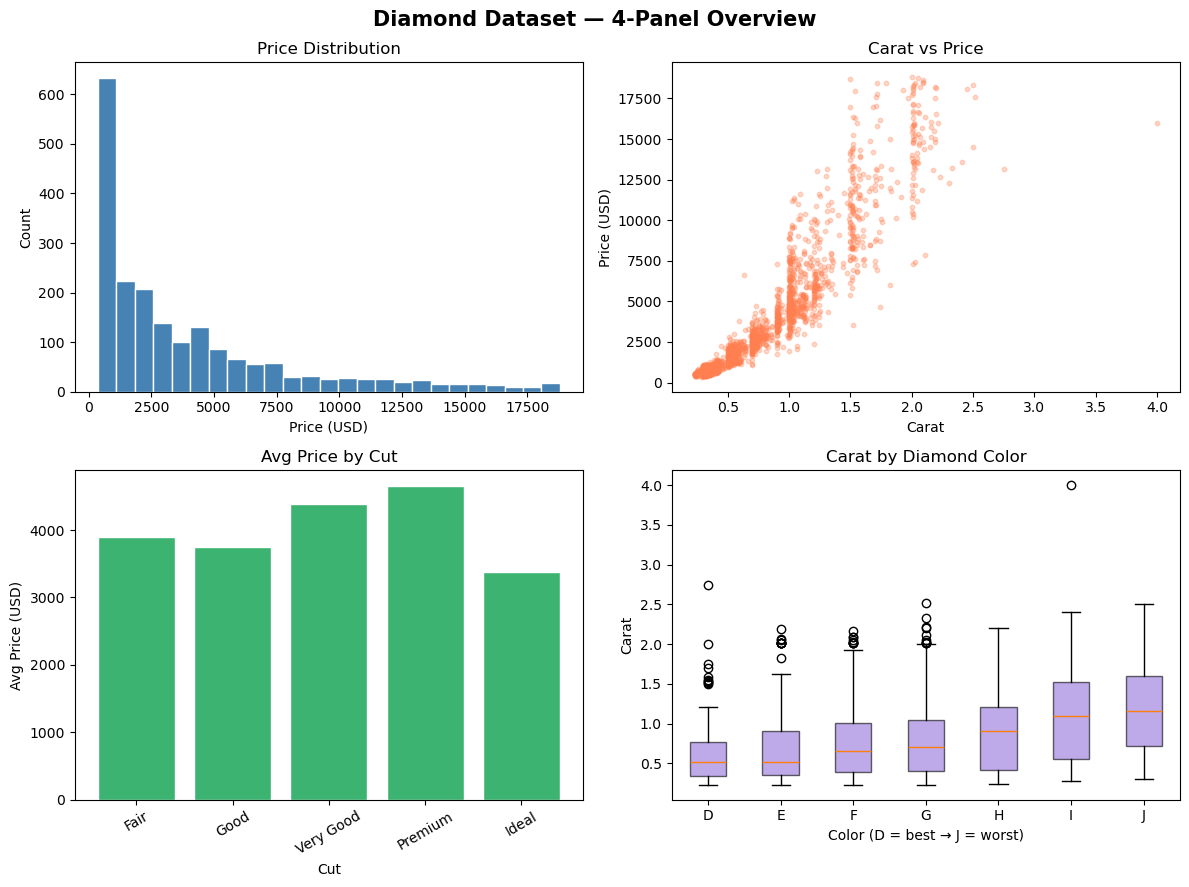

In [11]:
# ── 2×2 Subplot Grid ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Diamond Dataset — 4-Panel Overview', fontsize=15, fontweight='bold')

# ── Panel [0,0]: Histogram of price ───────────────────────────────────────
axes[0, 0].hist(df['price'], bins=25, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Count')

# ── Panel [0,1]: Scatter carat vs price ───────────────────────────────────
axes[0, 1].scatter(df['carat'], df['price'], alpha=0.3, s=10, color='coral')
axes[0, 1].set_title('Carat vs Price')
axes[0, 1].set_xlabel('Carat')
axes[0, 1].set_ylabel('Price (USD)')

# ── Panel [1,0]: Bar chart of avg price per cut ───────────────────────────
avg = df.groupby('cut')['price'].mean().reindex(cut_order)
axes[1, 0].bar(avg.index, avg.values, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Avg Price by Cut')
axes[1, 0].set_xlabel('Cut')
axes[1, 0].set_ylabel('Avg Price (USD)')
axes[1, 0].tick_params(axis='x', rotation=30)

# ── Panel [1,1]: Box plot of carat per color ──────────────────────────────
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
groups_c    = [df[df['color'] == c]['carat'].values for c in color_order]
axes[1, 1].boxplot(groups_c, labels=color_order, patch_artist=True,
                   boxprops=dict(facecolor='mediumpurple', alpha=0.6))
axes[1, 1].set_title('Carat by Diamond Color')
axes[1, 1].set_xlabel('Color (D = best → J = worst)')
axes[1, 1].set_ylabel('Carat')

plt.tight_layout()
plt.show()
# ► Tip: use fig.add_subplot(2, 2, n) for irregular layouts


In [12]:
# ── Saving a Figure ───────────────────────────────────────────────────────
# Uncomment these lines to save your figure to disk:
# plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')   # raster (PNG)
# plt.savefig('my_plot.svg', format='svg')                   # vector (SVG)

# ► Tip: always call savefig() BEFORE plt.show() — show() clears the figure
print("Tip: call plt.savefig('file.png', dpi=300, bbox_inches='tight') before plt.show()")


Tip: call plt.savefig('file.png', dpi=300, bbox_inches='tight') before plt.show()


---
## 5 · Seaborn – Statistical Charts <a id='5-seaborn'></a>

Seaborn wraps Matplotlib with **statistical smarts** — it can auto-compute
confidence intervals, add KDE curves, and split plots by hue/col/row with
one argument. Every Seaborn function returns a Matplotlib Axes, so you can
still use `plt.title()`, `plt.savefig()`, etc.


### 5.1 Scatter Plot with Hue

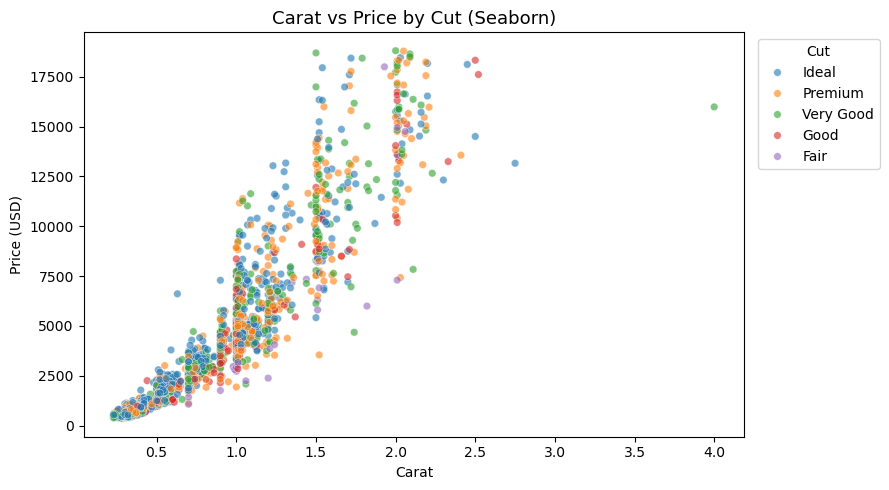

In [13]:
# ── Seaborn Scatter Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='cut',          # colour by category
    palette='tab10',    # colour palette
    alpha=0.6,
    s=30,               # marker size
    ax=ax
)

ax.set_title('Carat vs Price by Cut (Seaborn)', fontsize=13)
ax.set_xlabel('Carat')
ax.set_ylabel('Price (USD)')
ax.legend(title='Cut', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()
# ► Tip: add size='depth' to encode a 3rd continuous variable as marker size


### 5.2 Line Plot with Confidence Interval

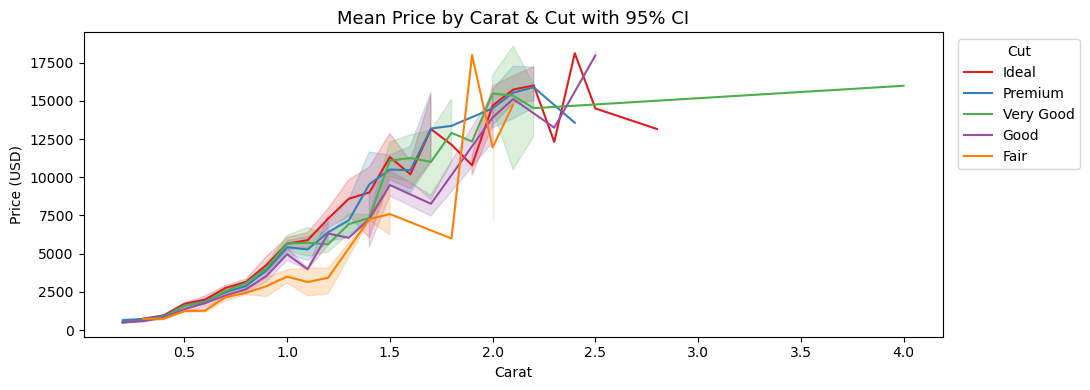

In [14]:
# ── Seaborn Line Plot ─────────────────────────────────────────────────────
# Seaborn automatically computes a 95 % confidence interval (shaded band)
fig = plt.figure(figsize=(11, 4))

sns.lineplot(
    data=df,
    x=df['carat'].round(1),   # bin carat to 1 decimal to smooth the line
    y='price',
    hue='cut',
    palette='Set1'
)

plt.title('Mean Price by Carat & Cut with 95% CI', fontsize=13)
plt.xlabel('Carat')
plt.ylabel('Price (USD)')
plt.legend(title='Cut', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 5.3 Box & Violin Plots

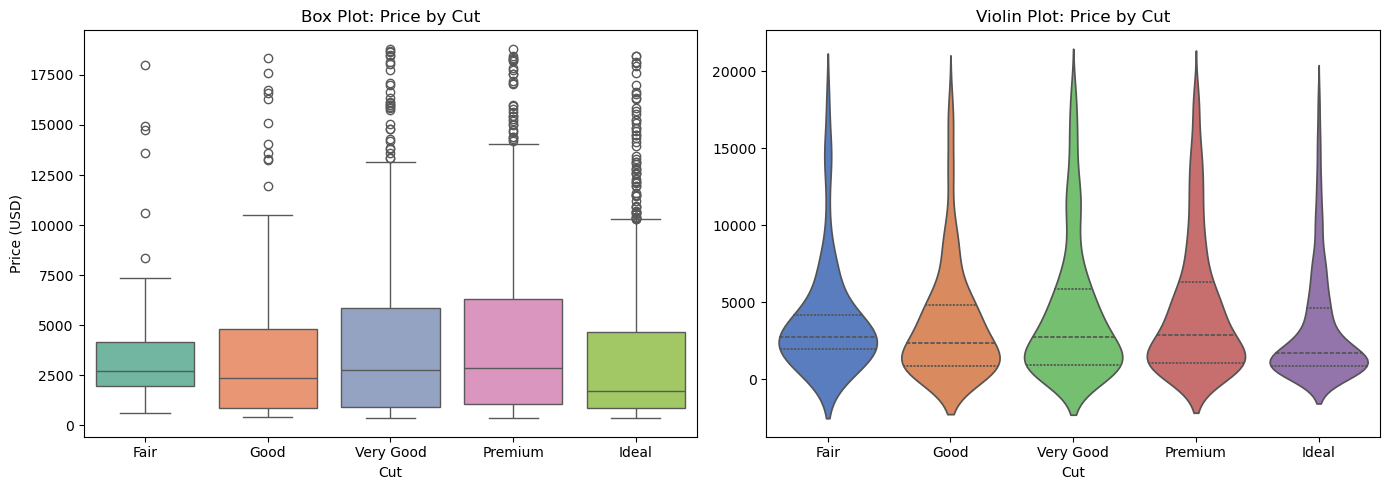

In [15]:
# ── Box Plot & Violin Plot side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot (left)
sns.boxplot(data=df, x='cut', y='price', order=cut_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Box Plot: Price by Cut')
axes[0].set_xlabel('Cut')
axes[0].set_ylabel('Price (USD)')

# Violin plot (right) – shows the full distribution shape
sns.violinplot(data=df, x='cut', y='price', order=cut_order,
               palette='muted', inner='quartile', ax=axes[1])
axes[1].set_title('Violin Plot: Price by Cut')
axes[1].set_xlabel('Cut')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
# ► Tip: inner='box' draws a mini box-plot inside each violin


### 5.4 Count Plot (Bar Chart for Categorical Data)

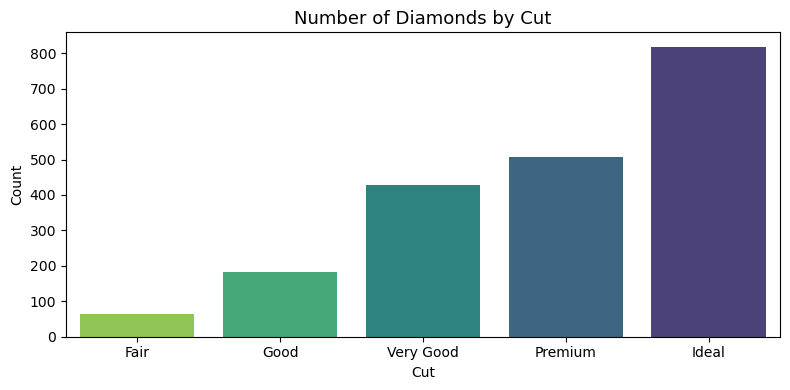

In [16]:
# ── Count Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

sns.countplot(
    data=df,
    x='cut',
    order=cut_order,
    hue='cut',           # colour by same variable (avoids FutureWarning)
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_title('Number of Diamonds by Cut', fontsize=13)
ax.set_xlabel('Cut')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### 5.5 Bar Plot (with Confidence Interval)

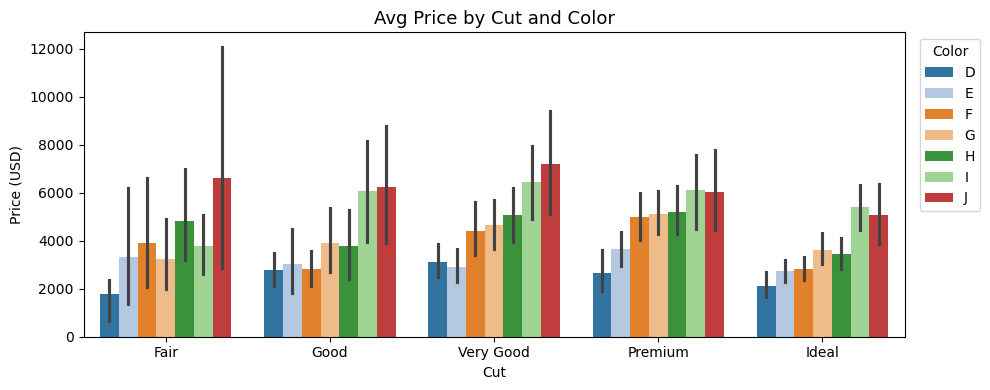

In [17]:
# ── Seaborn Bar Plot ──────────────────────────────────────────────────────
# Seaborn's barplot shows mean + 95 % CI automatically
fig = plt.figure(figsize=(10, 4))

sns.barplot(
    data=df,
    x='cut', y='price',
    hue='color',           # split bars by diamond color
    order=cut_order,
    palette='tab20',
    errorbar='ci'          # show confidence interval bars
)

plt.title('Avg Price by Cut and Color', fontsize=13)
plt.xlabel('Cut')
plt.ylabel('Price (USD)')
plt.legend(title='Color', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 5.6 Histogram + KDE

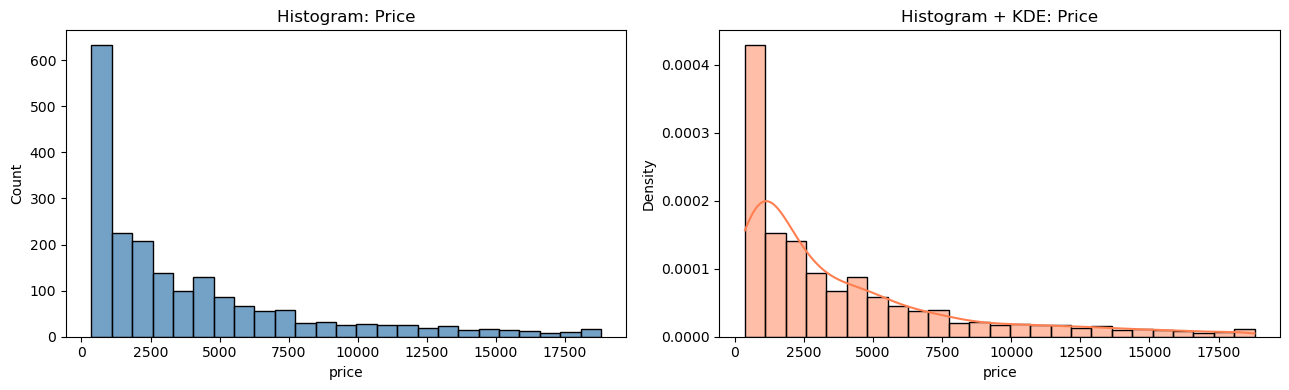

In [18]:
# ── Histplot (histogram + optional KDE) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plain histogram
sns.histplot(df['price'], bins=25, color='steelblue', ax=axes[0])
axes[0].set_title('Histogram: Price')

# Histogram + KDE (kernel density estimate)
sns.histplot(df['price'], bins=25, kde=True, color='coral',
             stat='density', ax=axes[1])
axes[1].set_title('Histogram + KDE: Price')

plt.tight_layout()
plt.show()


### 5.7 Heatmap (one-liner with annotations)

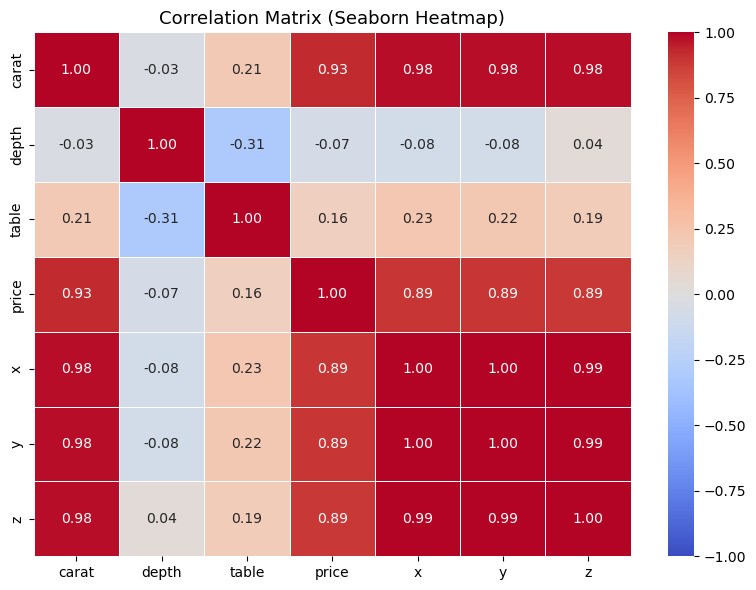

In [19]:
# ── Seaborn Heatmap ───────────────────────────────────────────────────────
corr = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,           # show correlation values in cells
    fmt='.2f',            # 2 decimal places
    cmap='coolwarm',      # diverging colour map (negative=blue, positive=red)
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Matrix (Seaborn Heatmap)', fontsize=13)

plt.tight_layout()
plt.show()


### 5.8 Pair Plot (all-vs-all scatter matrix)

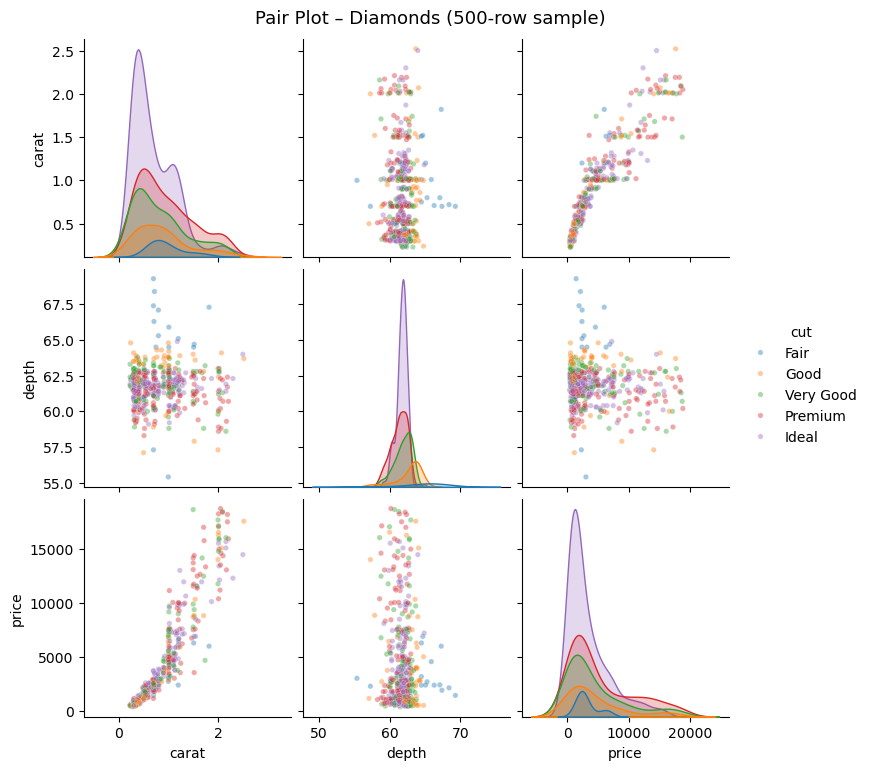

In [20]:
# ── Pair Plot ─────────────────────────────────────────────────────────────
# Shows scatter plots for every pair of numerical columns (diag = histogram)
small_df = df[['carat', 'depth', 'price', 'cut']].sample(500, random_state=0)

g = sns.pairplot(
    small_df,
    hue='cut',            # colour by cut
    hue_order=cut_order,
    palette='tab10',
    diag_kind='kde',      # diagonal: KDE instead of histogram
    plot_kws={'alpha': 0.4, 's': 15}
)
g.fig.suptitle('Pair Plot – Diamonds (500-row sample)', y=1.02, fontsize=13)
plt.show()
# ► Tip: this is one of the fastest EDA tools — run it early on any dataset


### 5.9 FacetGrid – Small Multiples

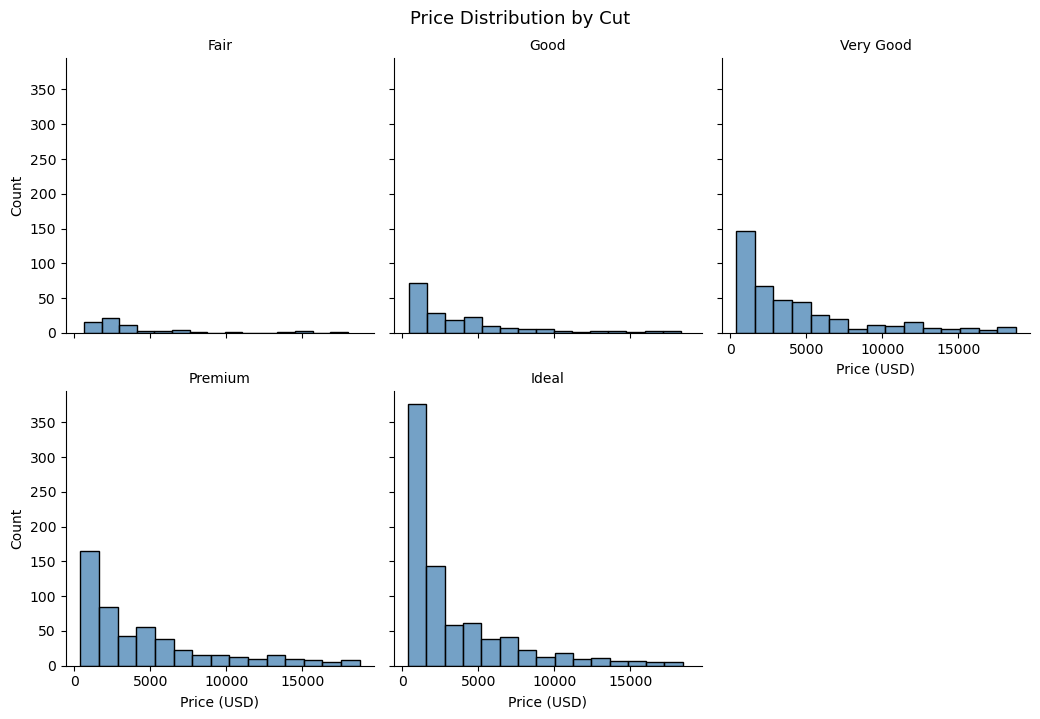

In [21]:
# ── FacetGrid (one panel per category) ───────────────────────────────────
g = sns.FacetGrid(df, col='cut', col_order=cut_order, col_wrap=3, height=3.5)
g.map(sns.histplot, 'price', bins=15, color='steelblue')
g.set_axis_labels('Price (USD)', 'Count')
g.set_titles(col_template='{col_name}')
g.fig.suptitle('Price Distribution by Cut', y=1.02, fontsize=13)
plt.show()
# ► Tip: swap sns.histplot for any other Seaborn / Matplotlib function


---
## 6 · Seaborn – Plot Customization <a id='6-seaborn-customization'></a>

These tricks work with **any** Seaborn (or Matplotlib) chart.


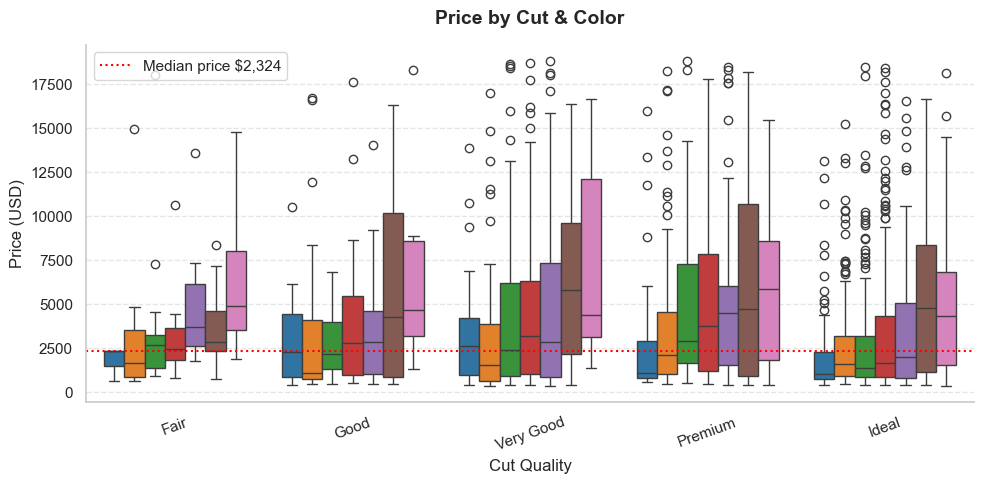

In [22]:
# ── All customization options in one demo plot ────────────────────────────

# 1. Set a theme  (whitegrid | darkgrid | white | dark | ticks)
sns.set_theme(style='whitegrid', context='notebook')

# 2. Choose a palette
sns.set_palette('Set1')  # deep | muted | pastel | bright | dark | colorblind | tab10

fig, ax = plt.subplots(figsize=(10, 5))

# Base plot
sns.boxplot(data=df, x='cut', y='price', hue='color',
            order=cut_order, palette='tab10', ax=ax,
            legend=False)

# 3. Title with custom font
ax.set_title('Price by Cut & Color', fontsize=14, fontweight='bold', pad=15)

# 4. Axis labels
ax.set_xlabel('Cut Quality', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)

# 5. Rotate x-tick labels
ax.tick_params(axis='x', rotation=20)

# 6. Custom grid
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# 7. Remove top & right spines
sns.despine()

# 8. Add a horizontal reference line
ax.axhline(df['price'].median(), color='red', linestyle=':', linewidth=1.5,
           label=f"Median price ${df['price'].median():,.0f}")
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


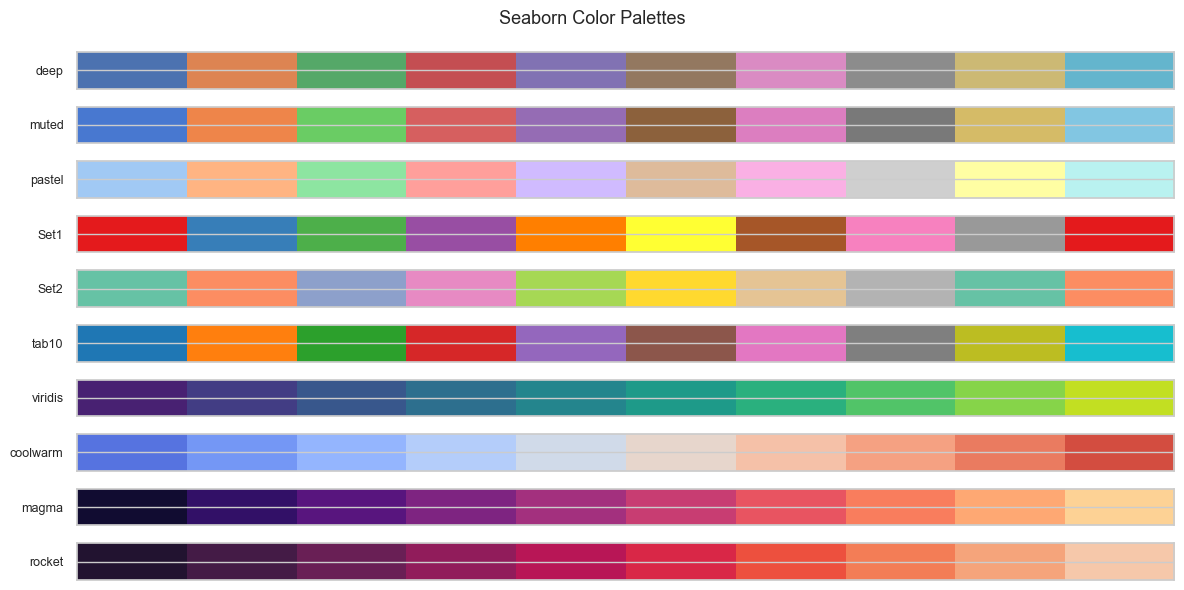

In [23]:
# ── Color Palette Quick-Reference ────────────────────────────────────────
palettes = ['deep', 'muted', 'pastel', 'Set1', 'Set2', 'tab10',
            'viridis', 'coolwarm', 'magma', 'rocket']

fig, axes = plt.subplots(len(palettes), 1, figsize=(12, len(palettes) * 0.6))
fig.suptitle('Seaborn Color Palettes', fontsize=13)

for ax, name in zip(axes, palettes):
    colors = sns.color_palette(name, 10)
    ax.imshow([colors], aspect='auto')
    ax.set_yticks([0])
    ax.set_yticklabels([name], fontsize=9)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


---
## 7 · Plotly – Interactive Charts <a id='7-plotly-interactive'></a>

Plotly charts are **interactive by default** — zoom, pan, hover, download.
`plotly.express` (px) is the high-level API: one line of code per chart.
`plotly.graph_objects` (go) gives full control for advanced customisation.

> **Tip:** hover over any data point to see its values.


In [24]:
# ── Quick dataset reset ───────────────────────────────────────────────────
# Use 10 % of diamonds for Plotly (faster rendering)
px_df = diamonds.sample(frac=0.10, random_state=10).reset_index(drop=True)
print(f"Plotly working dataset: {px_df.shape}")


Plotly working dataset: (5394, 10)


### 7.1 Scatter Plot

In [25]:
# ── Plotly Scatter Plot ───────────────────────────────────────────────────
fig = px.scatter(
    px_df,
    x='carat',
    y='price',
    color='cut',                           # colour by category
    size='price',                          # bubble size
    hover_data=['clarity', 'color'],       # extra info in tooltip
    title='Diamond Price vs Carat Weight',
    labels={'carat': 'Carat Weight', 'price': 'Price (USD)'},
    opacity=0.6,
    template='plotly_white'                # theme: plotly | plotly_dark | ggplot2 | seaborn
)
fig.show()
# ► Tip: click legend items to toggle categories on/off


### 7.2 Line Chart

In [26]:
# ── Plotly Line Chart ─────────────────────────────────────────────────────
line_px = (px_df.assign(carat_bin=px_df['carat'].round(1))
                .groupby(['carat_bin', 'cut'])['price']
                .mean().reset_index())

fig = px.line(
    line_px,
    x='carat_bin',
    y='price',
    color='cut',
    category_orders={'cut': cut_order},
    title='Mean Price by Carat & Cut',
    labels={'carat_bin': 'Carat', 'price': 'Mean Price (USD)'},
    template='plotly_white',
    markers=True
)
fig.show()


### 7.3 Bar Chart (with error bars)

In [27]:
# ── Plotly Bar Chart with Error Bars ─────────────────────────────────────
bar_px = (px_df.groupby('cut')['price']
               .agg(['mean', 'std'])
               .reindex(cut_order)
               .reset_index()
               .rename(columns={'mean': 'avg_price', 'std': 'std_price'}))

fig = px.bar(
    bar_px,
    x='cut',
    y='avg_price',
    error_y='std_price',           # standard deviation as error bars
    color='cut',
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='Average Diamond Price by Cut (± 1 SD)',
    labels={'avg_price': 'Avg Price (USD)', 'cut': 'Cut'},
    template='plotly_white'
)
fig.update_layout(showlegend=False)
fig.show()


### 7.4 Histogram

In [28]:
# ── Plotly Histogram ──────────────────────────────────────────────────────
fig = px.histogram(
    px_df,
    x='price',
    nbins=40,
    color='cut',
    barmode='overlay',       # 'stack' | 'group' | 'overlay'
    opacity=0.6,
    title='Price Distribution by Cut',
    labels={'price': 'Price (USD)'},
    template='plotly_white',
    category_orders={'cut': cut_order}
)
fig.show()


### 7.5 Box & Violin Plots

In [29]:
# ── Plotly Box Plot ───────────────────────────────────────────────────────
fig = px.box(
    px_df,
    x='cut',
    y='price',
    color='cut',
    points='outliers',          # 'all' | 'outliers' | 'suspectedoutliers' | False
    notched=False,              # True for notched box plots
    category_orders={'cut': cut_order},
    title='Price Distribution by Cut (Interactive Box Plot)',
    labels={'price': 'Price (USD)'},
    template='plotly_white'
)
fig.update_layout(showlegend=False)
fig.show()


In [30]:
# ── Plotly Violin Plot ────────────────────────────────────────────────────
fig = px.violin(
    px_df,
    x='cut',
    y='price',
    color='cut',
    box=True,                  # embed a box plot inside each violin
    points='suspectedoutliers',
    category_orders={'cut': cut_order},
    title='Price Distribution by Cut (Violin)',
    template='plotly_white'
)
fig.update_layout(showlegend=False)
fig.show()


### 7.6 Heatmap (Correlation Matrix)

In [31]:
# ── Plotly Heatmap ────────────────────────────────────────────────────────
corr_px = px_df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_px.values,
    x=corr_px.columns.tolist(),
    y=corr_px.columns.tolist(),
    colorscale='RdBu',         # RdBu | Viridis | Cividis | Plasma | Blues
    zmin=-1, zmax=1,
    text=corr_px.round(2).values,
    texttemplate='%{text}',
    hovertemplate='%{x} – %{y}: %{z:.2f}<extra></extra>'
))

fig.update_layout(
    title='Correlation Matrix (Plotly Heatmap)',
    template='plotly_white',
    width=600, height=500
)
fig.show()


### 7.7 Facet Grid (Small Multiples)

In [32]:
# ── Plotly Facet Scatter ──────────────────────────────────────────────────
fig = px.scatter(
    px_df,
    x='carat', y='price',
    color='cut',
    facet_col='clarity',       # one panel per clarity grade
    facet_col_wrap=4,          # wrap after 4 panels
    title='Price vs Carat by Cut & Clarity',
    opacity=0.5,
    template='plotly_white',
    category_orders={'cut': cut_order,
                     'clarity': clarity_order}
)
fig.update_traces(marker_size=4)
fig.show()


### 7.8 Animated Chart

In [33]:
# ── Plotly Animated Scatter ───────────────────────────────────────────────
# animation_frame steps through each clarity grade
fig = px.scatter(
    px_df,
    x='carat', y='price',
    color='cut',
    size='price',
    animation_frame='clarity',
    animation_group='cut',
    range_x=[0, px_df['carat'].max() + 0.1],
    range_y=[0, px_df['price'].max() + 500],
    title='Price vs Carat (animated by Clarity)',
    template='plotly_white',
    category_orders={'clarity': clarity_order, 'cut': cut_order}
)
fig.update_layout(width=800, height=500)
fig.show()
# ► Tip: press the ▶ button to auto-play, or drag the slider manually


### 7.9 Subplots (Plotly)

In [34]:
# ── Plotly Subplots ───────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Carat vs Price', 'Density Heatmap')
)

# Left panel: scatter
scatter_trace = px.scatter(px_df, x='carat', y='price').data[0]
fig.add_trace(scatter_trace, row=1, col=1)

# Right panel: density heatmap
heatmap_trace = px.density_heatmap(px_df, x='carat', y='price',
                                   nbinsx=20, nbinsy=20).data[0]
fig.add_trace(heatmap_trace, row=1, col=2)

fig.update_layout(
    title_text='Diamonds: Scatter & Density Side-by-Side',
    template='plotly_white',
    width=1000, height=450
)
fig.show()


### 7.10 3-D Scatter Plot

In [35]:
# ── Plotly 3D Scatter ─────────────────────────────────────────────────────
fig = px.scatter_3d(
    px_df,
    x='carat',
    y='depth',
    z='price',
    color='cut',
    size='price',
    opacity=0.5,
    title='3D: Carat, Depth, Price',
    template='plotly_white',
    category_orders={'cut': cut_order}
)
fig.update_traces(marker_size=3)
fig.show()
# ► Tip: click and drag to rotate; scroll to zoom


---
## 8 · Plotly – Maps <a id='8-plotly-maps'></a>

Plotly can draw **choropleth maps** (country/region shading) with built-in
world geography — no shapefiles needed. We use a small built-in country
dataset so the notebook runs fully offline.


In [36]:
# ── Built-in gapminder dataset (no wbdata needed) ────────────────────────
gapminder = px.data.gapminder()   # life expectancy, GDP, population by country/year
print(gapminder.shape)
gapminder.head(3)


(1704, 8)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4


In [37]:
# ── Choropleth Map – World GDP per Capita ────────────────────────────────
gap_2007 = gapminder[gapminder['year'] == 2007]

fig = px.choropleth(
    gap_2007,
    locations='iso_alpha',                       # ISO 3-letter country codes
    color='gdpPercap',                           # column to shade by
    hover_name='country',
    color_continuous_scale=px.colors.sequential.Plasma,
    title='GDP per Capita by Country (2007)',
    labels={'gdpPercap': 'GDP per Capita (USD)'}
)
fig.update_geos(
    projection_type='natural earth'  # 'natural earth' | 'orthographic' | 'mercator' | 'eckert4'
)
fig.update_layout(template='plotly_white', width=900, height=450)
fig.show()


In [38]:
# ── Animated Choropleth – Population Growth Over Time ─────────────────────
fig = px.choropleth(
    gapminder.sort_values('year'),
    locations='iso_alpha',
    color='pop',
    hover_name='country',
    animation_frame='year',            # slider steps through each year
    color_continuous_scale=px.colors.sequential.Viridis,
    title='World Population 1952–2007 (Animated)',
    labels={'pop': 'Population'},
    range_color=[gapminder['pop'].min(), gapminder['pop'].max()]
)
fig.update_geos(projection_type='natural earth')
fig.update_layout(width=900, height=450)
fig.show()
# ► Press ▶ to animate across years


In [39]:
# ── Bubble Map – Life Expectancy & GDP ───────────────────────────────────
fig = px.scatter_geo(
    gap_2007,
    locations='iso_alpha',
    color='continent',
    hover_name='country',
    size='pop',                        # bubble size = population
    projection='natural earth',
    title='Life Expectancy vs GDP per Capita (2007)',
    size_max=50,
    template='plotly_white'
)
fig.update_layout(width=900, height=450)
fig.show()


---
## 9 · Bokeh – Web-Ready Interactive Charts <a id='9-bokeh'></a>

Bokeh produces **browser-native interactive charts** with pan, zoom, and
hover tools built in. Key workflow:

```
from bokeh.plotting import figure, show, output_notebook
output_notebook()          # render inline in Jupyter
p = figure(...)            # create a plot
p.scatter(...)             # add glyphs
show(p)                    # display
```


In [42]:
# ── Bokeh Imports & Notebook Setup ───────────────────────────────────────
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import ColumnDataSource, HoverTool, ColorBar
from bokeh.transform import factor_cmap, linear_cmap
from bokeh.palettes import Category10, Viridis256
import bokeh.models as bkm

output_notebook()  # render plots inline (not in a separate browser tab)

# Re-use our 2 000-row sample
bk_df = df.copy()
source_all = ColumnDataSource(bk_df)
print("✅ Bokeh ready")


Loading BokehJS ...

✅ Bokeh ready


### 9.1 Scatter Plot with Hover Tool

In [43]:
# ── Bokeh Scatter with Hover ──────────────────────────────────────────────
source = ColumnDataSource(bk_df)

# Define what appears in the hover tooltip
hover = HoverTool(tooltips=[
    ('Carat', '@carat{0.2f}'),
    ('Price', '$@price{0,0}'),
    ('Cut',   '@cut'),
    ('Color', '@color'),
])

p = figure(
    title='Carat vs Price',
    x_axis_label='Carat',
    y_axis_label='Price (USD)',
    width=700, height=400,
    tools='pan,wheel_zoom,box_zoom,reset,save',
)
p.add_tools(hover)

p.scatter(
    'carat', 'price',
    source=source,
    size=5,
    alpha=0.5,
    color='steelblue'
)

show(p)


### 9.2 Vertical Bar Chart

In [44]:
# ── Bokeh Vertical Bar Chart ──────────────────────────────────────────────
cut_avg = bk_df.groupby('cut')['price'].mean().reindex(cut_order).reset_index()
src_bar = ColumnDataSource(cut_avg)

p = figure(
    x_range=cut_order,
    title='Average Price by Cut',
    x_axis_label='Cut',
    y_axis_label='Avg Price (USD)',
    width=650, height=400
)

p.vbar(
    x='cut',
    top='price',
    source=src_bar,
    width=0.6,
    color=factor_cmap('cut', palette=Category10[5], factors=cut_order),
    alpha=0.85
)

p.xgrid.grid_line_color = None   # remove vertical gridlines
p.y_range.start = 0

show(p)


### 9.3 Horizontal Bar Chart

In [45]:
# ── Bokeh Horizontal Bar Chart ───────────────────────────────────────────
p = figure(
    y_range=cut_order,
    title='Average Price by Cut (Horizontal)',
    x_axis_label='Avg Price (USD)',
    y_axis_label='Cut',
    width=650, height=400
)

p.hbar(
    y='cut',
    right='price',
    source=src_bar,
    height=0.5,
    color='coral',
    alpha=0.8
)

p.ygrid.grid_line_color = None

show(p)


### 9.4 Line Chart

In [46]:
# ── Bokeh Line Chart ──────────────────────────────────────────────────────
line_data = (bk_df.assign(carat_bin=bk_df['carat'].round(1))
                  .groupby('carat_bin')['price']
                  .mean().reset_index())
src_line  = ColumnDataSource(line_data)

p = figure(
    title='Mean Price by Carat',
    x_axis_label='Carat',
    y_axis_label='Mean Price (USD)',
    width=700, height=380
)

p.line('carat_bin', 'price', source=src_line,
       line_width=2, color='darkgreen', legend_label='Mean price')
p.circle('carat_bin', 'price', source=src_line,
         size=6, color='darkgreen', alpha=0.7)

p.legend.location = 'top_left'
show(p)


### 9.5 Circle / Bubble Chart

In [47]:
# ── Bokeh Circle Plot ─────────────────────────────────────────────────────
# Map price to a colour using a continuous palette
mapper = linear_cmap(
    field_name='price',
    palette=Viridis256,
    low=bk_df['price'].min(),
    high=bk_df['price'].max()
)

p = figure(
    title='Price vs Table Width (colour = price)',
    x_axis_label='Table (%)',
    y_axis_label='Price (USD)',
    width=700, height=420
)

p.circle(
    'table', 'price',
    source=source_all,
    size=5,
    color=mapper,
    alpha=0.5
)

color_bar = ColorBar(color_mapper=mapper['transform'], width=12, label_standoff=6)
p.add_layout(color_bar, 'right')

show(p)


---
## 10 · Quick-Reference Cheatsheet <a id='10-cheatsheet'></a>

### Choose Your Chart Type

| Goal | Best chart | Library recommendation |
|------|-----------|----------------------|
| Show trend over time | Line chart | Matplotlib / Plotly |
| Compare categories | Bar chart | Seaborn / Plotly |
| Distribution shape | Histogram + KDE | Seaborn / Plotly |
| Two continuous variables | Scatter plot | Seaborn / Plotly |
| Compare distributions | Box / Violin | Seaborn / Plotly |
| Correlations | Heatmap | Seaborn / Plotly |
| Part of a whole | Pie / Donut | Matplotlib / Plotly |
| All pairs at once | Pair plot | Seaborn |
| Interactive dashboard | Any | Plotly / Bokeh |
| Geographic data | Choropleth map | Plotly |
| 3-D data | 3-D Scatter | Plotly |
| Web-embedded chart | Any | Bokeh |

---

### Library Strengths at a Glance

| | Matplotlib | Seaborn | Plotly | Bokeh |
|---|---|---|---|---|
| Static publication charts | ✅ Best | ✅ Great | ✅ OK | ❌ |
| Statistical auto-summaries | ❌ | ✅ Best | ✅ OK | ❌ |
| Interactive tooltips | ❌ | ❌ | ✅ Best | ✅ Great |
| Animated charts | ❌ | ❌ | ✅ Best | ❌ |
| Geographic maps | ❌ | ❌ | ✅ Best | ❌ |
| Web embedding | ❌ | ❌ | ✅ Great | ✅ Best |
| Learning curve | Medium | Low | Low | Medium |

---

### Most-Used Parameters

```python
# ── Matplotlib ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(W, H))
ax.set_title('…'); ax.set_xlabel('…'); ax.set_ylabel('…')
ax.grid(True, linestyle='--', alpha=0.4)
plt.savefig('out.png', dpi=300, bbox_inches='tight')

# ── Seaborn ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')          # theme
sns.set_palette('Set2')                   # colours
sns.despine()                             # remove top/right spines
# hue, size, style → encode extra variables without writing loops

# ── Plotly Express ────────────────────────────────────────────────────────
px.scatter(df, x=…, y=…, color=…, size=…, facet_col=…, animation_frame=…,
           template='plotly_white', title='…', labels={…})
# template options: plotly | plotly_white | plotly_dark | ggplot2 | seaborn | none

# ── Bokeh ─────────────────────────────────────────────────────────────────
p = figure(title=…, x_axis_label=…, y_axis_label=…, width=…, height=…,
           tools='pan,wheel_zoom,box_zoom,reset,save')
p.add_tools(HoverTool(tooltips=[('Label', '@column')]))
show(p)
```

---

### Common Color Palettes

| Library | Usage | Examples |
|---------|-------|---------|
| Matplotlib | `cmap=` | `viridis`, `plasma`, `coolwarm`, `Blues`, `RdBu` |
| Seaborn | `palette=` | `Set1`, `Set2`, `tab10`, `muted`, `deep`, `pastel`, `colorblind` |
| Plotly | `color_continuous_scale=` | `Viridis`, `Plasma`, `RdBu`, `Blues` |
| Plotly qual | `color_discrete_sequence=` | `px.colors.qualitative.Set2` |
| Bokeh | `palette=` | `Category10[N]`, `Viridis256`, `Turbo256` |

---

*Happy plotting! 🎨*
